<a href="https://colab.research.google.com/github/KarlaMichelleSorianoSanhez/Simulacion-I/blob/main/t%C3%A9cnicas_de_remuestreo_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#TÉCNICAS DE REMUESTREO

## BOOTSTRAP


**NOMBRE**: Karla Michelle Soriano Sánchez

**INSTRUCCIONES**:  Utilizar la muestra obsrvada

$$
\{35,42,38,40,45,37,39,41,44,36,43,40\}
$$

para aplicar la técnica de remuestreo Bootstrap.

A partir de la muestra original se deberán generar 1000 muestras Bootstrap de tamaño 12 utilizando muestreo con reemplazo.

Para cada muestra Bootstrap $B$ se calculará la media muestral.

Finalmente se deberá:

- Obtener la media de las 1000 medias Bootstrap.
- Calcular la desviación estándar Bootstrap.
- Determinar los percentiles 2.5% y 97.5%.
- Construir un intervalo de confianza Bootstrap del 95%.
- Interpretar los resultados obtenidos.


**OBJETIVO**: Aplicar la técnica Bootstrap para estudiar la variabilidad de la media a partir de una muestra observada.

Mediante la generación de remuestras con reemplazo se estimará la distribución Bootstrap

### Técnicas de Remuestreo

Las técnicas de remuestreo son procedimientos estadísticos que permiten estudiar el comportamiento de un estimador utilizando únicamente la información contenida en una muestra observada.
La idea principal consiste en generar nuevas muestras a partir de los datos originales y analizar cómo cambia el estadístico de interés.
Estas técnicas son especialmente útiles cuando la distribución poblacional es desconocida o cuando resulta difícil obtener expresiones analíticas para medir la variabilidad de un estimador.
Una de las técnicas de remuestreo más utilizadas es el método Bootstrap.


### Método Bootstrap

Supongamos que

$$
X_1,X_2,\ldots,X_n
$$

son variables aleatorias independientes con función de distribución común

$$
F.
$$

Se desea estimar un parámetro poblacional

$$
\theta(F)
$$

mediante un estimador

$$
g(X_1,X_2,\ldots,X_n).
$$

La calidad del estimador puede evaluarse mediante el Error Cuadrático Medio (ECM), definido por

$$
ECM(F)
=
E_F
\left[
\left(
g(X_1,\ldots,X_n)-\theta(F)
\right)^2
\right].
$$

Sin embargo, en la práctica la distribución poblacional

$$
F
$$

generalmente es desconocida.

Por esta razón, el método Bootstrap propone sustituir la distribución poblacional por una aproximación construida a partir de los propios datos observados.


### Distribución Empírica

Sea

$$
x_1,x_2,\ldots,x_n
$$

la muestra observada.

La distribución empírica asociada a la muestra se define mediante

$$
F_n(x)
=
\frac{
\text{Número de observaciones }X_i \leq x
}
{n}.
$$

La distribución empírica asigna la misma probabilidad a cada observación de la muestra.

De esta manera, cada dato observado representa una posible realización de la población de interés.

Bootstrap utiliza esta distribución empírica como sustituto de la distribución poblacional desconocida.


### Idea Fundamental del Método Bootstrap

La idea principal del método Bootstrap consiste en considerar que la muestra observada contiene toda la información disponible acerca de la población.

A partir de esta muestra se generan nuevas muestras aleatorias mediante muestreo con reemplazo.

El procedimiento se resume en los siguientes pasos:

1. Tomar la muestra original.
2. Generar una nueva muestra de igual tamaño mediante muestreo con reemplazo.
3. Calcular el estadístico de interés.
4. Repetir el procedimiento un gran número de veces.
5. Analizar la distribución obtenida para el estadístico.

En esta actividad el estadístico de interés será la media muestral.



### Muestreo con Reemplazo

En Bootstrap las observaciones se seleccionan con reemplazo.

Esto significa que después de seleccionar un dato, éste regresa nuevamente a la muestra original y puede ser elegido otra vez.

Por lo tanto, una misma observación puede aparecer varias veces dentro de una misma remuestra Bootstrap, mientras que otras observaciones podrían no aparecer.

Esta característica es fundamental para reproducir la variabilidad presente en la distribución empírica.


## Datos de la Muestra

La muestra utilizada en esta actividad corresponde a 12 tiempos de entrega:

$$
\{35,42,38,40,45,37,39,41,44,36,43,40\}.
$$

El tamaño de la muestra es

$$
n=12.
$$

A partir de esta información se generarán

$$
B=1000
$$

muestras Bootstrap.

Cada remuestra tendrá nuevamente tamaño

$$
n=12
$$

y será obtenida mediante muestreo con reemplazo.


## Planteamiento del Procedimiento

Para aplicar la técnica Bootstrap se utilizará la muestra observada como una aproximación de la población.

Posteriormente se generarán

$$
B=1000
$$

remuestras Bootstrap.

Para cada remuestra se calculará la media muestral

$$
\bar X^{*}.
$$

El conjunto de las 1000 medias Bootstrap permitirá construir una aproximación de la distribución muestral de la media.

A partir de esta distribución se obtendrán:

- La media Bootstrap.
- La desviación estándar Bootstrap.
- Los percentiles 2.5% y 97.5%.
- El intervalo de confianza Bootstrap al 95%.

En la siguiente sección se realizará la implementación computacional del procedimiento descrito.



In [59]:
# Importación de bibliotecas

import numpy as np  #facilitará los cálculos numéricos y la generación de remuestras Bootstrap
import matplotlib.pyplot as  ptl #representar gráficamente la distribución de las medias obtenidas

## Definición de la Muestra

La muestra observada contiene los tiempos de entrega proporcionados en el enunciado.

Estos datos constituyen la información disponible acerca de la población y serán utilizados para construir la distribución empírica sobre la cual se basa el procedimiento Bootstrap.

La muestra contiene

$$
n=12
$$

observaciones.

In [60]:
#muestra observada
datos = np.array(
    [35, 42, 38, 40, 45, 37, 39, 41, 44, 36, 43, 40]
)

# Mostrar la muestra
datos

array([35, 42, 38, 40, 45, 37, 39, 41, 44, 36, 43, 40])

## Parámetros del Procedimiento Bootstrap

El método Bootstrap requiere especificar el número de remuestras que serán generadas.

En esta actividad se utilizarán

$$
B=1000
$$

remuestras Bootstrap, tal como se indica en las instrucciones.

Cada remuestra tendrá nuevamente tamaño

$$
n=12.
$$



In [61]:
# Número de réplicas Bootstrap
B = 1000

# Tamaño de la muestra original
n = len(datos)

print("Tamaño de la muestra:", n)
print("Número de réplicas Bootstrap:", B)

Tamaño de la muestra: 12
Número de réplicas Bootstrap: 1000


## Generación de las Muestras Bootstrap

La idea central del método Bootstrap consiste en generar nuevas muestras a partir de la muestra original utilizando muestreo con reemplazo.

Cada remuestra tendrá tamaño

$$
n=12.
$$

Como el muestreo se realiza con reemplazo, una misma observación puede aparecer varias veces dentro de una remuestra, mientras que otras observaciones podrían no aparecer.

Para cada remuestra Bootstrap se calculará la media muestral.

Estas medias serán almacenadas para construir posteriormente la distribución Bootstrap de la media.



In [68]:
# Lista donde se almacenarán las medias Bootstrap
medias_bootstrap = []

# Generación de las remuestras Bootstrap
for i in range(B):
  # Generar una remuestra Bootstrap de tamaño n
  muestra_bootstrap = np.random.choice(
      datos,
      size=n,
      replace=True
    )

  # Calcular la media de la remuestra
  media_muestra = np.mean(muestra_bootstrap)

  # Almacenar la media obtenida
  medias_bootstrap.append(media_muestra)

# Convertir la lista a arreglo NumPy
medias_bootstrap = np.array(medias_bootstrap)

## Interpretación de las Medias Bootstrap

Cada elemento almacenado en el arreglo

$$
\bar X_1^{*},
\bar X_2^{*},
\ldots,
\bar X_{1000}^{*}
$$

representa la media obtenida a partir de una remuestra Bootstrap.

El conjunto de estas medias constituye una aproximación de la distribución muestral de la media.

A partir de esta distribución se podrán estimar medidas de tendencia central, dispersión e intervalos de confianza.



In [63]:
# Mostrar las primeras medias Bootstrap

print("Primeras 10 medias Bootstrap:\n")

print(medias_bootstrap[:10])

Primeras 10 medias Bootstrap:

[39.5        39.16666667 39.33333333 38.58333333 39.08333333 40.58333333
 41.25       39.66666667 41.66666667 41.08333333]


## Cálculo de los Estadísticos Bootstrap

Una vez obtenida la distribución Bootstrap de la media, se procede a calcular los estadísticos solicitados.

En particular se determinarán:

- La media Bootstrap.
- La desviación estándar Bootstrap.
- El percentil 2.5%.
- El percentil 97.5%.

Estos valores permitirán cuantificar la variabilidad de la media y construir posteriormente un intervalo de confianza Bootstrap del 95%.


In [70]:
# Media Bootstrap

media_boot = np.mean(medias_bootstrap)
media_boot



np.float64(39.98008333333333)

In [71]:
# Desviación estándar Bootstrap
error_boot = np.std(
    medias_bootstrap,
    ddof=1
)

error_boot


np.float64(0.857271619679367)

In [73]:
# Percentiles para el intervalo de confianza
p2_5 = np.percentile(
    medias_bootstrap,
    2.5
)
p2_5



np.float64(38.333333333333336)

In [74]:
p97_5 = np.percentile(
    medias_bootstrap,
    97.5
)
p97_5

np.float64(41.666666666666664)

In [65]:
# ==========================================================
# Mostrar resultados Bootstrap
# ==========================================================

print("RESULTADOS DEL MÉTODO BOOTSTRAP")
print("=" * 50)

print(f"Tamaño de muestra (n): {n}")
print(f"Número de réplicas Bootstrap (B): {B}")

print("\nEstadísticos Bootstrap")
print("-" * 50)

print(f"Media Bootstrap: {media_boot:.4f}")
print(f"Desviación estándar Bootstrap: {error_boot:.4f}")

print("\nIntervalo de confianza Bootstrap (95%)")
print("-" * 50)

print(f"Percentil 2.5% : {p2_5:.4f}")
print(f"Percentil 97.5% : {p97_5:.4f}")

print(
    f"\nIC Bootstrap 95% = "
    f"[{p2_5:.4f}, {p97_5:.4f}]"
)

RESULTADOS DEL MÉTODO BOOTSTRAP
Tamaño de muestra (n): 12
Número de réplicas Bootstrap (B): 1000

Estadísticos Bootstrap
--------------------------------------------------
Media Bootstrap: 39.9984
Desviación estándar Bootstrap: 0.8648

Intervalo de confianza Bootstrap (95%)
--------------------------------------------------
Percentil 2.5% : 38.3333
Percentil 97.5% : 41.6667

IC Bootstrap 95% = [38.3333, 41.6667]


Los estadísticos obtenidos resumen la información contenida en las 1000 remuestras Bootstrap.

La media Bootstrap proporciona una estimación del valor esperado de la media muestral.

La desviación estándar Bootstrap mide la variabilidad de dicha estimación.

Finalmente, los percentiles 2.5% y 97.5% permiten construir un intervalo de confianza Bootstrap del 95%.


## Construcción del Intervalo de Confianza Bootstrap

Una de las aplicaciones más importantes del método Bootstrap consiste en la construcción de intervalos de confianza.

En esta actividad se utilizará el método percentil.

Este método consiste en utilizar directamente los percentiles de la distribución Bootstrap obtenida a partir de las 1000 remuestras.

En particular, se consideran los percentiles:

$$
P_{2.5}
$$

y

$$
P_{97.5}.
$$

Por lo tanto, el intervalo de confianza Bootstrap al 95% está dado por

$$
IC_{95\%}
=
\left(
P_{2.5},
P_{97.5}
\right).
$$

Este intervalo proporciona un rango de valores plausibles para la media poblacional de los tiempos de entrega.



In [66]:
print("INTERVALO DE CONFIANZA BOOTSTRAP AL 95%")
print("=" * 50)

print(
    f"IC95% = ({p2_5:.4f}, {p97_5:.4f})"
)

INTERVALO DE CONFIANZA BOOTSTRAP AL 95%
IC95% = (38.3333, 41.6667)


Las 1000 medias Bootstrap obtenidas constituyen una aproximación de la distribución muestral de la media.

Para analizar visualmente esta distribución se construirá un histograma.

Además, se representarán gráficamente:

- La media Bootstrap.
- El percentil 2.5%.
- El percentil 97.5%.

Estas referencias permitirán visualizar el intervalo de confianza Bootstrap al 95%.


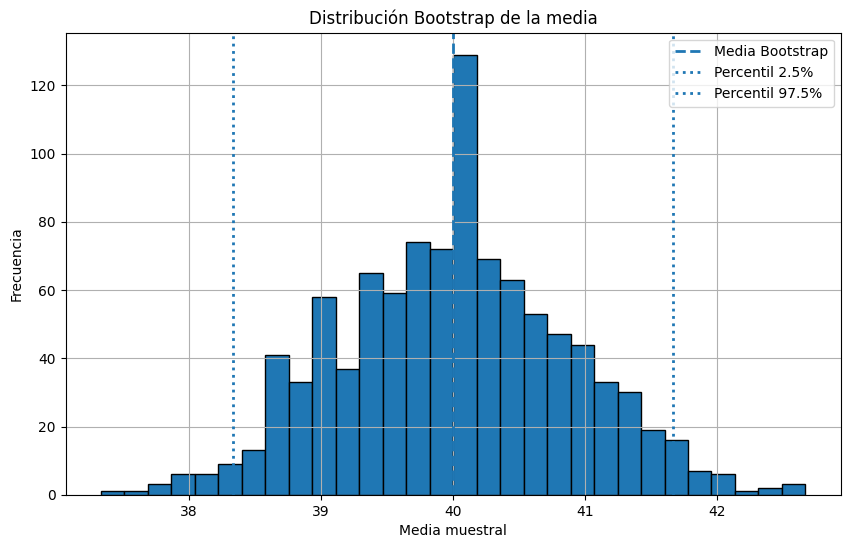

In [67]:
# ==========================================================
# Histograma de las medias Bootstrap
# ==========================================================
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))

plt.hist(
    medias_bootstrap,
    bins=30,
    edgecolor="black"
)

# ==========================================================
# Media Bootstrap
# ==========================================================

plt.axvline(
    media_boot,
    linestyle="--",
    linewidth=2,
    label="Media Bootstrap"
)

# ==========================================================
# Percentil 2.5%
# ==========================================================

plt.axvline(
    p2_5,
    linestyle=":",
    linewidth=2,
    label="Percentil 2.5%"
)

# ==========================================================
# Percentil 97.5%
# ==========================================================

plt.axvline(
    p97_5,
    linestyle=":",
    linewidth=2,
    label="Percentil 97.5%"
)

plt.title("Distribución Bootstrap de la media")

plt.xlabel("Media muestral")

plt.ylabel("Frecuencia")

plt.legend()

plt.grid(True)

plt.show()